In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn as sk
from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import svm
import matplotlib
import xgboost

In [7]:
data = pd.read_csv("../data/TrafficVolume.csv")
data = pd.DataFrame(data)

In [8]:
data.head()

,holiday,temp,rain,snow,weather,date,Time,traffic_volume
0,NaN,288.28,0.0,0.0,Clouds,02-10-2012,09:00:00,5545
1,NaN,289.36,0.0,0.0,Clouds,02-10-2012,10:00:00,4516
2,NaN,289.58,0.0,0.0,Clouds,02-10-2012,11:00:00,4767
3,NaN,290.13,0.0,0.0,Clouds,02-10-2012,12:00:00,5026
4,NaN,291.14,0.0,0.0,Clouds,02-10-2012,13:00:00,4918


In [9]:
data.describe()

,temp,rain,snow,traffic_volume
count,48151.000000,48202.000000,48192.000000,48204.000000
mean,281.205351,0.334278,0.000222,3259.818355
std,13.343675,44.790062,0.008169,1986.860670
min,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1193.000000
50%,282.460000,0.000000,0.000000,3380.000000
75%,291.810000,0.000000,0.000000,4933.000000
max,310.070000,9831.300000,0.510000,7280.000000


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   holiday         61 non-null     object 
 1   temp            48151 non-null  float64
 2   rain            48202 non-null  float64
 3   snow            48192 non-null  float64
 4   weather         48155 non-null  object 
 5   date            48204 non-null  object 
 6   Time            48204 non-null  object 
 7   traffic_volume  48204 non-null  int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 2.9+ MB


In [11]:
data

,holiday,temp,rain,snow,weather,date,Time,traffic_volume
0,NaN,288.28,0.0,0.0,Clouds,02-10-2012,09:00:00,5545
1,NaN,289.36,0.0,0.0,Clouds,02-10-2012,10:00:00,4516
2,NaN,289.58,0.0,0.0,Clouds,02-10-2012,11:00:00,4767
3,NaN,290.13,0.0,0.0,Clouds,02-10-2012,12:00:00,5026
4,NaN,291.14,0.0,0.0,Clouds,02-10-2012,13:00:00,4918
...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,Clouds,30-09-2018,19:00:00,3543
48200,NaN,282.76,0.0,0.0,Clouds,30-09-2018,20:00:00,2781
48201,NaN,282.73,0.0,0.0,Thunderstorm,30-09-2018,21:00:00,2159
48202,NaN,282.09,0.0,0.0,Clouds,30-09-2018,22:00:00,1450


In [12]:
data.isnull().sum()

holiday           48143
temp                 53
rain                  2
snow                 12
weather              49
date                  0
Time                  0
traffic_volume        0
dtype: int64

In [13]:
data['temp'] = data['temp'].fillna(data['temp'].mean())
data['rain'] = data['rain'].fillna(data['rain'].mean())
data['snow'] = data['snow'].fillna(data['snow'].mean())

In [14]:
from collections import Counter
print(Counter(data['weather']))

Counter({'Clouds': 15144, 'Clear': 13383, 'Mist': 5942, 'Rain': 5665, 'Snow': 2875, 'Drizzle': 1818, 'Haze': 1359, 'Thunderstorm': 1033, 'Fog': 912, nan: 49, 'Smoke': 20, 'Squall': 4})


In [15]:
data['weather'] = data['weather'].fillna('Clouds')

In [16]:
print(data.dtypes)

holiday            object
temp              float64
rain              float64
snow              float64
weather            object
date               object
Time               object
traffic_volume      int64
dtype: object


In [17]:
cor = data.select_dtypes(include='number').corr()
print(cor)

                    temp      rain      snow  traffic_volume
temp            1.000000  0.009070 -0.019758        0.130034
rain            0.009070  1.000000 -0.000090        0.004714
snow           -0.019758 -0.000090  1.000000        0.000735
traffic_volume  0.130034  0.004714  0.000735        1.000000


<Axes: >

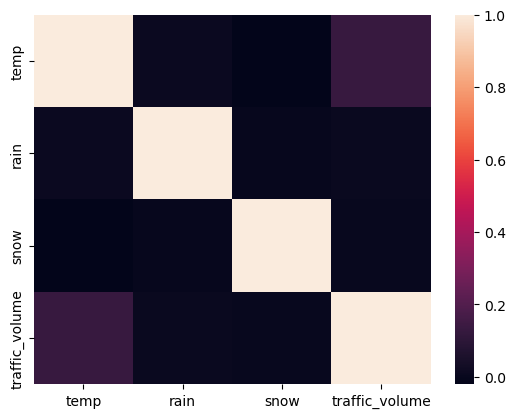

In [18]:
sns.heatmap(cor)

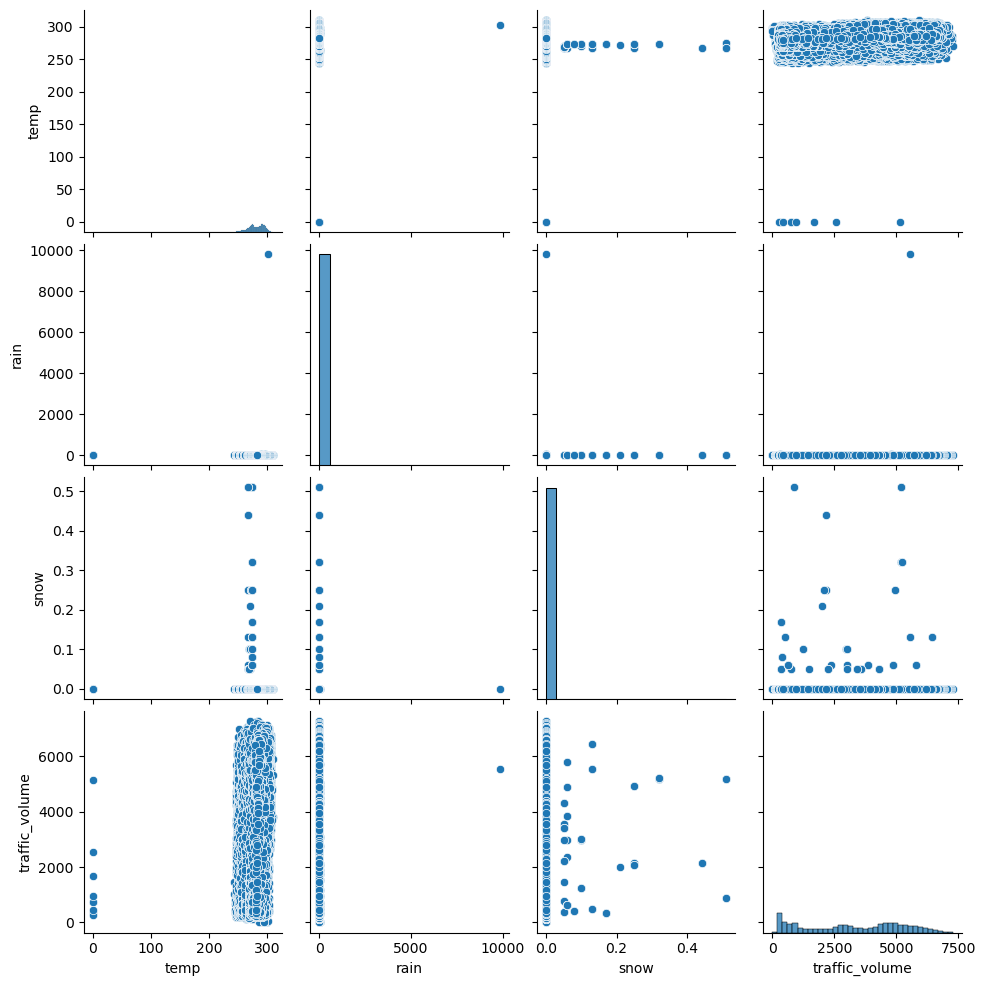

In [19]:
sns.pairplot(data)

<Axes: >

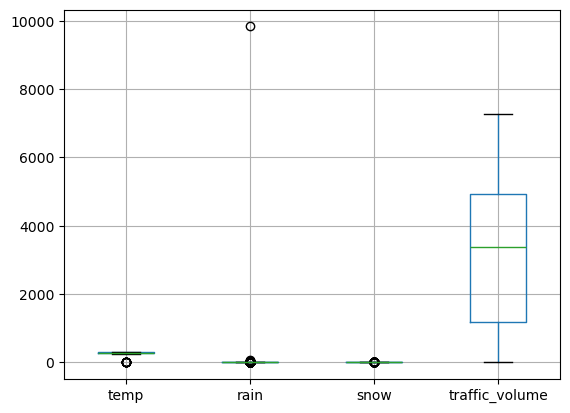

In [20]:
data.boxplot()

In [21]:
#spliting date
data[['day','month','year']] = data['date'].str.split('-', expand = True)

In [22]:
data[['hours', 'minutes', 'seconds']] = data['Time'].str.split(':', expand = True)

In [23]:
data.drop(columns = ['date', 'Time'], axis = 1, inplace = True)

In [24]:
data.head()

,holiday,temp,rain,snow,weather,traffic_volume,day,month,year,hours,minutes,seconds
0,NaN,288.28,0.0,0.0,Clouds,5545,02,10,2012,09,00,00
1,NaN,289.36,0.0,0.0,Clouds,4516,02,10,2012,10,00,00
2,NaN,289.58,0.0,0.0,Clouds,4767,02,10,2012,11,00,00
3,NaN,290.13,0.0,0.0,Clouds,5026,02,10,2012,12,00,00
4,NaN,291.14,0.0,0.0,Clouds,4918,02,10,2012,13,00,00


In [25]:
y = data['traffic_volume']
x = data.drop(columns = 'traffic_volume', axis = 1)

In [26]:
names = x.columns

In [27]:
x = pd.DataFrame(x, columns = names)

In [28]:
x.head()

,holiday,temp,rain,snow,weather,day,month,year,hours,minutes,seconds
0,NaN,288.28,0.0,0.0,Clouds,02,10,2012,09,00,00
1,NaN,289.36,0.0,0.0,Clouds,02,10,2012,10,00,00
2,NaN,289.58,0.0,0.0,Clouds,02,10,2012,11,00,00
3,NaN,290.13,0.0,0.0,Clouds,02,10,2012,12,00,00
4,NaN,291.14,0.0,0.0,Clouds,02,10,2012,13,00,00


In [29]:
x.dtypes

holiday     object
temp       float64
rain       float64
snow       float64
weather     object
day         object
month       object
year        object
hours       object
minutes     object
seconds     object
dtype: object

In [30]:
from sklearn.preprocessing import LabelEncoder
le_weather = LabelEncoder()
le_holiday = LabelEncoder()
x['weather'] = le_weather.fit_transform(x['weather'])
x['holiday'] = le_holiday.fit_transform(x['holiday'])
for col in ['day', 'month', 'year', 'hours', 'minutes', 'seconds']:
    x[col] = pd.to_numeric(x[col], errors='coerce')

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [34]:
from sklearn import tree
from sklearn import linear_model
from sklearn import ensemble
from sklearn import svm
import xgboost

In [35]:
lin_reg = linear_model.LinearRegression()
dTree = tree.DecisionTreeRegressor()
rand = ensemble.RandomForestRegressor()
svr = svm.SVR()
XGB = xgboost.XGBRegressor()

In [37]:
lin_reg.fit(xtrain, ytrain)
dTree.fit(xtrain, ytrain)
rand.fit(xtrain, ytrain)
svr.fit(xtrain, ytrain)
XGB.fit(xtrain, ytrain)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [38]:
p1 = lin_reg.predict(xtrain)
p2 = dTree.predict(xtrain)
p3 = rand.predict(xtrain)
p4 = svr.predict(xtrain)
p5 = XGB.predict(xtrain)

In [39]:
from sklearn import metrics

In [40]:
print(metrics.r2_score(ytrain, p1))
print(metrics.r2_score(ytrain, p2))
print(metrics.r2_score(ytrain, p3))
print(metrics.r2_score(ytrain, p4))
print(metrics.r2_score(ytrain, p5))

0.13330638927295624
1.0
0.9772358894194326
0.24372940536574972
0.8723706007003784


In [41]:
p1 = lin_reg.predict(xtest)
p2 = dTree.predict(xtest)
p3 = rand.predict(xtest)
p4 = svr.predict(xtest)
p5 = XGB.predict(xtest)

In [42]:
print(metrics.r2_score(ytest, p1))
print(metrics.r2_score(ytest, p2))
print(metrics.r2_score(ytest, p3))
print(metrics.r2_score(ytest, p4))
print(metrics.r2_score(ytest, p5))

0.13615906122216836
0.6951289654682813
0.8353858778625489
0.24742926205652993
0.8370459079742432


In [44]:
import pickle
pickle.dump(rand, open(r"../flask/model.pkl", 'wb'))
pickle.dump(le_weather, open(r"../flask/encoder_weather.pkl", 'wb'))
pickle.dump(le_holiday, open(r"../flask/encoder_holiday.pkl", 'wb'))
pickle.dump(scaler, open(r"../flask/scaler.pkl", 'wb'))

In [45]:
features_values = [["Columbus Day", 32, 0, 0, "Clouds", 2025, 12, 21, 12, 21, 21]]
names = ['holiday', 'temp', 'rain', 'snow', 'weather', 'year', 'month', 'day',
             'hours', 'minutes', 'seconds']
pred = pd.DataFrame(features_values, columns=names)

# Encode categorical columns using saved encoders
pred['weather'] = le_weather.transform(pred['weather'])
pred['holiday'] = le_holiday.transform(pred['holiday'])

# Convert remaining columns to numeric
for col in ['year', 'month', 'day', 'hours', 'minutes', 'seconds']:
    pred[col] = pd.to_numeric(pred[col], errors='coerce')

# Reorder columns to match training data order
pred = pred[['holiday', 'temp', 'rain', 'snow', 'weather', 'day', 'month', 'year', 'hours', 'minutes', 'seconds']]

# Scale using the saved scaler
pred_scaled = scaler.transform(pred)

# Predict using the best model (Random Forest)
prediction = rand.predict(pred_scaled)
print(f"Predicted Traffic Volume: {int(prediction[0])} vehicles")

Predicted Traffic Volume: 3349 vehicles
